In [3]:
from pycocotools.coco import COCO
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import requests
from io import BytesIO
import matplotlib.patches as patches

In [4]:
annotation_file = r'C:\Users\lilli\Desktop\MIDOG++\images\MIDOGpp.json'
coco = COCO(annotation_file)

#category names
cats = coco.loadCats(coco.getCatIds())
cat_names = [cat['name'] for cat in cats]
print(f'Categories: {cat_names}')

#image IDs
img_ids = coco.getImgIds()
print(f'Number of images: {len(img_ids)}')

loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Categories: ['mitotic figure', 'not mitotic figure']
Number of images: 553


In [5]:
#checking the field of annotations
ann_ids = coco.getAnnIds()
if len(ann_ids) > 0:
    sample_ann = coco.loadAnns(ann_ids[0])[0]
    #the annotation structure is a box around the mitotic figure
    print('Annotation fields:', sample_ann.keys())
    print('\nSample annotation:')
    print(sample_ann)

Annotation fields: dict_keys(['bbox', 'category_id', 'image_id', 'labels', 'id'])

Sample annotation:
{'bbox': [4336, 346, 4386, 396], 'category_id': 2, 'image_id': 1, 'labels': [2, 2], 'id': 1}


In [7]:
def visualize_coco_annotations(coco, img_id, image_dir):
    #load the image and its info 
    img_info = coco.loadImgs(img_id)[0]
    #path on computer to the image
    img_path = f"{image_dir}/{img_info['file_name']}"
    img = Image.open(img_path)
    
    #annotations for this image
    ann_ids = coco.getAnnIds(imgIds=img_id)
    anns = coco.loadAnns(ann_ids)
    
    #create figure to show the annotations
    fig, ax = plt.subplots(1, figsize=(12, 8))
    ax.imshow(img)
    
    #different color for each category (MF or not MF)
    colors = plt.cm.rainbow(np.linspace(0, 1, len(coco.getCatIds())))
    cat_to_color = {cat_id: colors[i] for i, cat_id in enumerate(coco.getCatIds())}
    
    #add each annotation
    for ann in anns:
        cat_id = ann['category_id']
        cat_name = coco.loadCats(cat_id)[0]['name']
        color = cat_to_color[cat_id]
        
        #Bbox is in [x1, y1, x2, y2] format
        x1, y1, x2, y2 = ann['bbox']
        width = x2 - x1
        height = y2 - y1
        
        #adding the bounding box
        rect = patches.Rectangle((x1, y1),
                                 width,
                                 height,
                                 linewidth=2,
                                 edgecolor=color,
                                 facecolor='none')
        ax.add_patch(rect)
        
        #label 
        ax.text(x1, y1-5, cat_name, 
               color='white', fontsize=10, weight='bold',
               bbox=dict(facecolor=color, alpha=0.7, edgecolor='none'))
    
    ax.axis('off')
    plt.title(f"Image: {img_info['file_name']} ({len(anns)} annotations)", 
             fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    #annotation details
    print(f"\nImage ID: {img_info['file_name']}")
    print(f"Dimensions: {img_info['width']}x{img_info['height']}")
    print(f"Number of annotations: {len(anns)}")
    for i, ann in enumerate(anns):
        cat_name = coco.loadCats(ann['category_id'])[0]['name']
        x1, y1, x2, y2 = ann['bbox']
        area = (x2 - x1) * (y2 - y1)
        print(f'  {i+1}. {cat_name} - bbox: [{x1}, {y1}, {x2}, {y2}] (area: {area:.0f})')

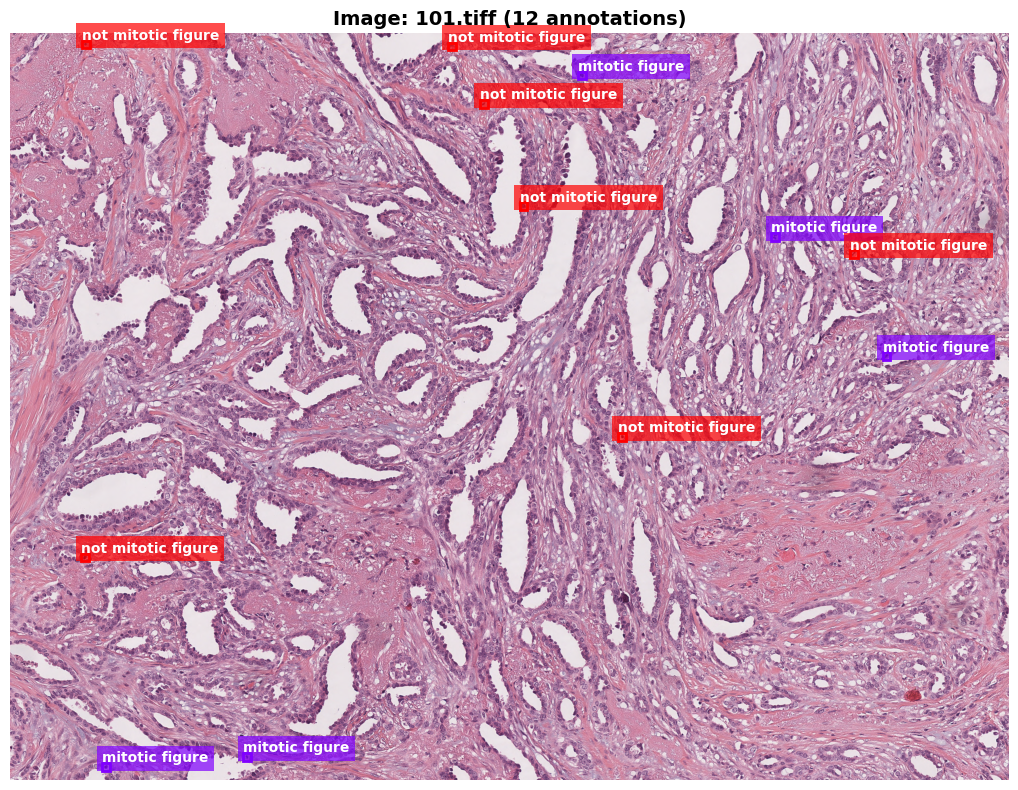


Image ID: 101.tiff
Dimensions: 6475x4840
Number of annotations: 12
  1. not mitotic figure - bbox: [2838, 59, 2888, 109] (area: 2500)
  2. not mitotic figure - bbox: [3045, 433, 3095, 483] (area: 2500)
  3. not mitotic figure - bbox: [465, 46, 515, 96] (area: 2500)
  4. mitotic figure - bbox: [3680, 247, 3730, 297] (area: 2500)
  5. not mitotic figure - bbox: [3303, 1095, 3353, 1145] (area: 2500)
  6. mitotic figure - bbox: [4934, 1294, 4984, 1344] (area: 2500)
  7. not mitotic figure - bbox: [5444, 1406, 5494, 1456] (area: 2500)
  8. mitotic figure - bbox: [5657, 2067, 5707, 2117] (area: 2500)
  9. not mitotic figure - bbox: [3941, 2591, 3991, 2641] (area: 2500)
  10. not mitotic figure - bbox: [462, 3372, 512, 3422] (area: 2500)
  11. mitotic figure - bbox: [599, 4731, 649, 4781] (area: 2500)
  12. mitotic figure - bbox: [1511, 4666, 1561, 4716] (area: 2500)


In [24]:
image_dir = 'C:/Users/lilli/Desktop/MIDOG++/images/'
img_id = img_ids[100]
visualize_coco_annotations(coco, img_id, image_dir)

In [11]:
from albumentations import Resize, Compose
from cellseg_models_pytorch.models.cellpose import CellPose
from cellseg_models_pytorch.utils import FileHandler
from cellseg_models_pytorch.transforms.albu_transforms import MinMaxNormalization

C:\Users\lilli\cell_seg\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\lilli\cell_seg\lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


In [15]:
#code taken from the cellpose website: https://cellpose.readthedocs.io/en/latest/index.html 
import numpy as np
import matplotlib.pyplot as plt
from cellpose import models, io
from cellpose.io import imread
io.logger_setup()

model = models.CellposeModel(gpu=False)

# list of files (I am staring with only one file)
files = ['C:/Users/lilli/Desktop/MIDOG++/images/004.tiff']

imgs = [imread(f) for f in files]
nimg = len(imgs)

masks, flows, styles = model.eval(imgs)

creating new log file
2026-01-22 10:04:08,246 [INFO] WRITING LOG OUTPUT TO C:\Users\lilli\.cellpose\run.log
2026-01-22 10:04:08,247 [INFO] 
cellpose version: 	4.0.8 
platform:       	win32 
python version: 	3.10.0 
torch version:  	2.10.0+cpu
2026-01-22 10:04:08,248 [INFO] >>>> using CPU
2026-01-22 10:04:08,249 [INFO] >>>> using CPU
2026-01-22 10:04:10,968 [INFO] Downloading: "https://huggingface.co/mouseland/cellpose-sam/resolve/main/cpsam" to C:\Users\lilli\.cellpose\models\cpsam



100%|█████████████████████████████████████████████████████████████████████████████| 1.15G/1.15G [00:35<00:00, 35.2MB/s]


2026-01-22 10:04:47,498 [WARNING] Found more than 3 channels, only using first 3
2026-01-22 10:04:47,799 [INFO] processing image with (5412, 7215) HW, and 3 channels


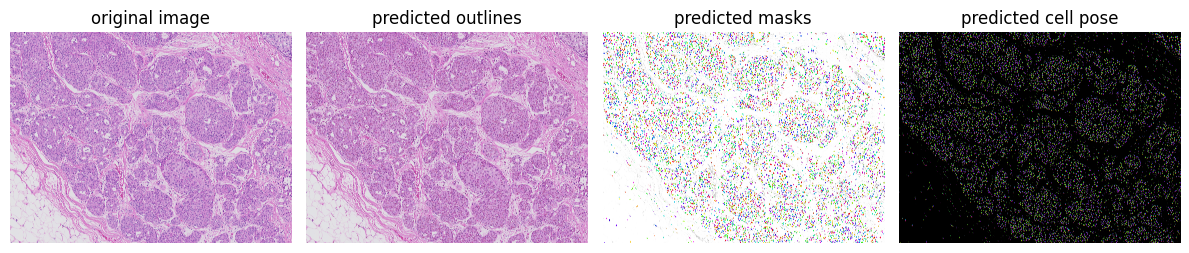

In [22]:
from cellpose import plot
from skimage.color import rgba2rgb

for idx in range(nimg):
    maski = masks[idx]
    flowi = flows[idx][0]
    img_rgb = rgba2rgb(imgs[idx])

    fig = plt.figure(figsize=(12,5))
    plot.show_segmentation(fig, img_rgb, maski, flowi)
    plt.tight_layout()
    plt.show()

In [27]:
#trying StartDist
from stardist.models import StarDist2D

# prints a list of available models
StarDist2D.from_pretrained()

# creates a pretrained model
model = StarDist2D.from_pretrained('2D_versatile_fluo')

There are 4 registered models for 'StarDist2D':

Name                  Alias(es)
────                  ─────────
'2D_versatile_fluo'   'Versatile (fluorescent nuclei)'
'2D_versatile_he'     'Versatile (H&E nuclei)'
'2D_paper_dsb2018'    'DSB 2018 (from StarDist 2D paper)'
'2D_demo'             None
Found model '2D_versatile_fluo' for 'StarDist2D'.
5320433/5320433 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


OSError: [WinError 1314] A required privilege is not held by the client: '2D_versatile_fluo_extracted' -> 'C:\\Users\\lilli\\.keras\\models\\StarDist2D\\2D_versatile_fluo\\2D_versatile_fluo'